In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

## Genome-wide scores

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
gnomw_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

gnomw_anno_config_df


category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
"""vep_consequences""","""consequence_start_lost""","""#E65100""","""VEP Start Lost""",1
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1


In [3]:
gnomw_anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

plof_annos = ['consequence_stop_lost', 'consequence_start_lost', 'loftee_hc', 'loftee_lc', 'consequence_splice_donor_variant', 'consequence_splice_acceptor_variant', 'consequence_stop_gained']

selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw', 'abexp_abs_max']

gnomw_anno = (
    gnomw_anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(selected_annos))
        .union(set(plof_annos))
    )
    .collect(engine='streaming')

    .unpivot(
        index=set(['id', 'region', 'gene_name']).union(plof_annos),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        gnomw_anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        gnomw_anno_config_df.rename({
            'annotation':'plof_type', 
            'annotation_dir':'plof_dir',
            'label':'label_plof'
        }).select(['plof_type', 'plof_dir', 'label_plof']).unique(),
        on='plof_type'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

gnomw_anno

id,region,gene_name,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,str,f32,str,i32,str,str,i8,i8,str,f32
"""chr1:202750657:A:G""","""ENSG00000117139""","""KDM5B""","""gpn_star_llr_calibrated_mean""",-10.449175,"""consequence_splice_donor_varia…",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Splice Donor""",10.449175
"""chr1:177958131:C:T""","""ENSG00000120341""","""SEC16B""","""gpn_star_llr_calibrated_mean""",-11.513997,"""consequence_splice_donor_varia…",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Splice Donor""",11.513997
"""chr19:11240297:G:T""","""ENSG00000130173""","""ANGPTL8""","""gpn_star_llr_calibrated_mean""",-8.80215,"""consequence_splice_donor_varia…",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Splice Donor""",8.80215
"""chr11:125677796:C:T""","""ENSG00000134940""","""ACRV1""","""gpn_star_llr_calibrated_mean""",-6.061315,"""consequence_splice_donor_varia…",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Splice Donor""",6.061315
"""chr19:11241555:G:A""","""ENSG00000130173""","""ANGPTL8""","""gpn_star_llr_calibrated_mean""",-9.114981,"""consequence_splice_donor_varia…",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Splice Donor""",9.114981
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr1:32292172:G:A""","""ENSG00000116478""","""HDAC1""","""abexp_abs_max""",2.523542,"""consequence_start_lost""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Start Lost""",2.523542
"""chr4:183099492:A:C""","""ENSG00000151718""","""WWC2""","""abexp_abs_max""",0.152217,"""consequence_start_lost""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Start Lost""",0.152217
"""chr13:33285636:C:G""","""ENSG00000133121""","""STARD13""","""abexp_abs_max""",0.567187,"""consequence_start_lost""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Start Lost""",0.567187


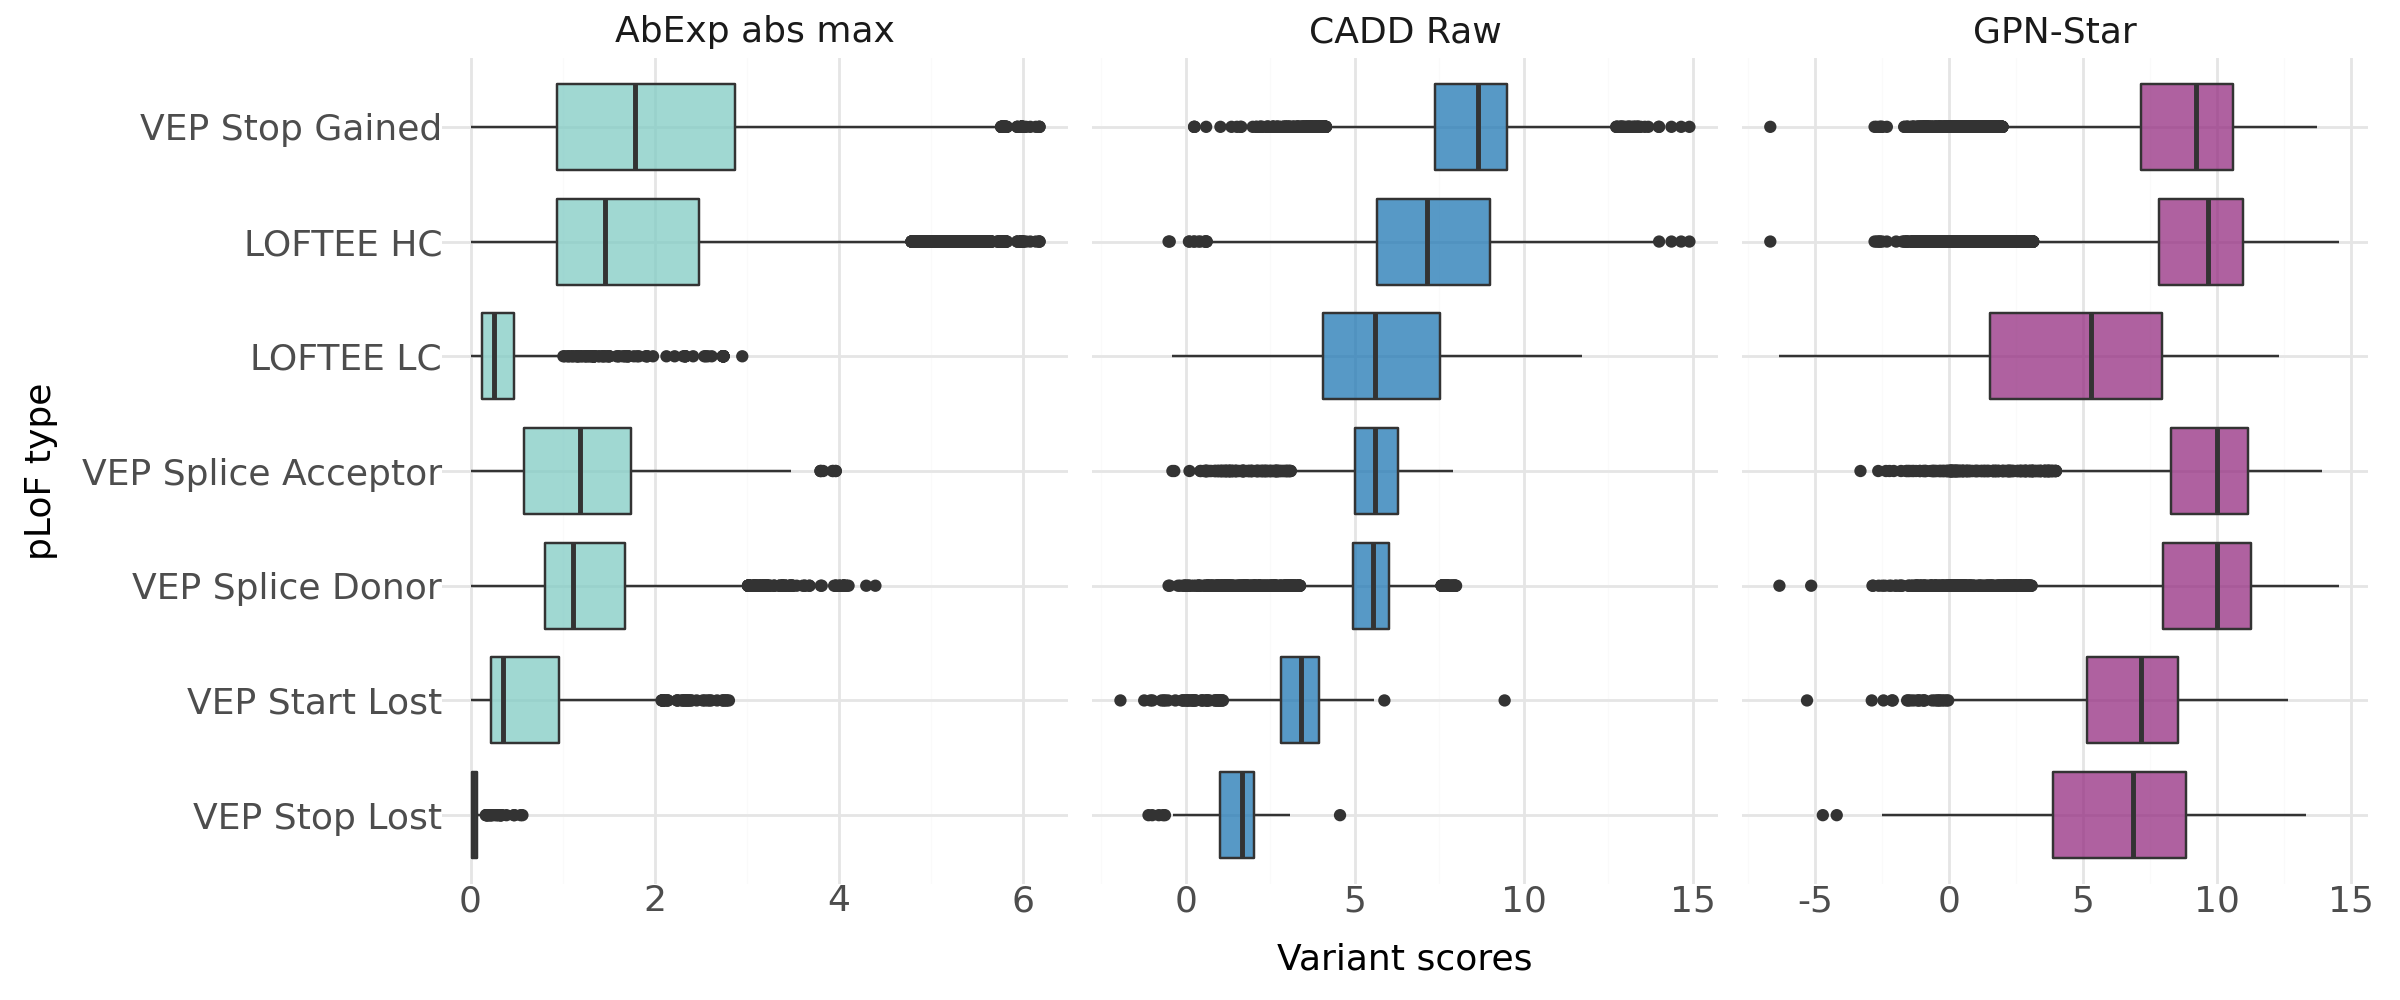

In [4]:
# Prepare for plotting (order by CADD Raw median corr_beta)
med_df = gnomw_anno.drop_nans().filter(pl.col('annotation')=='cadd_raw').group_by("label_plof").agg(
    median_score_dircorr = pl.col("annotation_score_dircorr").median(),
)

gnomw_anno_pd = med_df.join(gnomw_anno, on='label_plof').to_pandas()

gnomw_anno_pd['label_plof'] = pd.Categorical(
    gnomw_anno_pd['label_plof'],
    categories=gnomw_anno_pd.sort_values('median_score_dircorr', ascending=True)['label_plof'].unique(),
    ordered=True
)

color_dict = dict(zip(gnomw_anno_config_df['label'], gnomw_anno_config_df['color']))

(
    ggplot(
        gnomw_anno_pd,
        aes(y='annotation_score_dircorr', x='label_plof', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_x', ncol=3)
    + scale_fill_manual(values=color_dict)
    + labs(
        x='pLoF type',
        y='Variant scores'
    )
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(12, 5),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Mean Pheno

In [5]:
# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [6]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

# existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .join(
        gnomw_anno[['id', 'region']].unique().lazy(),
        on=['id', 'region']
    )
    # .filter(
    #     # Choose CDS
    #     (pl.col('vep_cds_relaxed')==True)
    #     # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

    #     # Only SNPs
    #     # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    # )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(plof_annos))
    )
    # .with_columns(
    #     start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    # )
    .collect(engine='streaming')
)

anno

consequence_splice_donor_variant,gene_name,loftee_lc,region,id,loftee_hc,consequence_stop_gained,consequence_stop_lost,consequence_splice_acceptor_variant,consequence_start_lost
i32,str,i8,str,str,i8,i32,i32,i32,i32
0,"""SLC22A2""",0,"""ENSG00000112499""","""chr6:160258595:C:A""",1,1,0,0,0
0,"""PDGFRA""",0,"""ENSG00000134853""","""chr4:54270637:C:T""",1,1,0,0,0
0,"""NF1""",0,"""ENSG00000196712""","""chr17:31357308:C:T""",1,1,0,0,0
0,"""SLC13A1""",0,"""ENSG00000081800""","""chr7:123128888:G:A""",1,1,0,0,0
0,"""ECE1""",0,"""ENSG00000117298""","""chr1:21221844:T:G""",1,0,0,1,0
…,…,…,…,…,…,…,…,…,…
1,"""CFTR""",0,"""ENSG00000001626""","""chr7:117592658:G:A""",1,0,0,0,0
0,"""SMAD6""",0,"""ENSG00000137834""","""chr15:66703475:G:T""",1,1,0,0,0
0,"""STARD13""",0,"""ENSG00000133121""","""chr13:33129253:A:T""",1,1,0,0,0


In [7]:
melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(plof_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=plof_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).unique(),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    .filter(
        (pl.col('annotation_score') != 0)
    )
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr16:2037982:T:C""","""ENSG00000065054""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr20:3804961:A:G""","""ENSG00000101224""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr14:32154946:T:G""","""ENSG00000100852""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr8:144507000:A:T""","""ENSG00000167701""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr5:141516852:T:A""","""ENSG00000131504""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
…,…,…,…,…,…,…
"""chr7:117595039:T:A""","""ENSG00000001626""","""consequence_stop_gained""",1.0,"""plof_consequences""",1,1.0
"""chr10:99807474:C:T""","""ENSG00000023839""","""consequence_stop_gained""",1.0,"""plof_consequences""",1,1.0
"""chr17:39725401:T:G""","""ENSG00000141736""","""consequence_stop_gained""",1.0,"""plof_consequences""",1,1.0


In [8]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [9]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)


plof_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    
    # C. Group by variant/gene to get average phenotype effect per variant
    .group_by(['id', 'region', 'gene_name'])
    .agg(
        n_phenos = pl.col('phenotype').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )

    # C. Group by annotation and aggregate
    # .group_by(['annotation'])
    # .agg(
    #     n_vars = pl.col('id').n_unique(),
    #     median_pheno = pl.col('mean_pheno_value_dircor').median(),
    #     mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
    #     std_pheno = pl.col('mean_pheno_value_dircor').std(),
    # )
    # .with_columns(
    #     se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    # )
    # .with_columns(
    #     ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
    #     ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    # )
    .collect(engine='streaming')
)

plof_pheno_df

id,region,gene_name,n_phenos,median_pheno,mean_pheno,std_pheno
str,str,str,u64,f64,f64,f64
"""chr6:131850108:T:C""","""ENSG00000197594""","""ENPP1""",1,0.788079,0.788079,0.0
"""chr3:141540531:A:C""","""ENSG00000155903""","""RASA2""",3,0.56207,0.476372,0.381409
"""chr1:177965126:G:A""","""ENSG00000120341""","""SEC16B""",1,0.34268,0.34268,0.0
"""chr6:160258605:G:T""","""ENSG00000112499""","""SLC22A2""",1,0.348181,0.348181,0.0
"""chr1:212387012:G:C""","""ENSG00000065600""","""PACC1""",5,0.121797,-0.111406,0.310729
…,…,…,…,…,…,…
"""chr8:25323865:C:T""","""ENSG00000147459""","""DOCK5""",2,0.467425,0.467425,0.300473
"""chr1:153933481:A:T""","""ENSG00000198837""","""DENND4B""",1,1.117408,1.117408,0.0
"""chr12:132583570:C:A""","""ENSG00000112787""","""FBRSL1""",1,0.688219,0.688219,0.0


In [10]:
avg_plof_plot = (
    plof_pheno_df
    .join(
        gnomw_anno.unique(), 
        on=['id', 'region', 'gene_name']
    )
    # .to_pandas()
)

avg_plof_plot

id,region,gene_name,n_phenos,median_pheno,mean_pheno,std_pheno,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,u64,f64,f64,f64,str,f32,str,i32,str,str,i8,i8,str,f32
"""chr4:147857655:G:T""","""ENSG00000071205""","""ARHGAP10""",1,0.073262,0.073262,0.0,"""cadd_raw""",5.9413,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",5.9413
"""chr17:69102930:G:A""","""ENSG00000154262""","""ABCA6""",1,0.517165,0.517165,0.0,"""abexp_abs_max""",0.846716,"""consequence_stop_gained""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Stop Gained""",0.846716
"""chr12:21196945:G:C""","""ENSG00000134538""","""SLCO1B1""",2,0.154771,0.154771,0.336529,"""cadd_raw""",4.726747,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",4.726747
"""chr17:69110942:T:C""","""ENSG00000154262""","""ABCA6""",1,0.032884,0.032884,0.0,"""cadd_raw""",6.737622,"""loftee_hc""",1,"""#1f77b4""","""CADD Raw""",1,1,"""LOFTEE HC""",6.737622
"""chr12:111447329:G:A""","""ENSG00000111252""","""SH2B3""",2,0.969458,0.969458,0.256158,"""abexp_abs_max""",2.507801,"""loftee_hc""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""LOFTEE HC""",2.507801
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr17:35557522:C:A""","""ENSG00000236320""","""SLFN14""",3,0.321769,-0.05279,0.666645,"""abexp_abs_max""",0.0,"""consequence_stop_gained""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Stop Gained""",0.0
"""chr7:87454593:C:T""","""ENSG00000005471""","""ABCB4""",1,-0.31505,-0.31505,0.0,"""abexp_abs_max""",0.260069,"""consequence_splice_acceptor_va…",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Splice Acceptor""",0.260069
"""chr3:172786540:G:T""","""ENSG00000114346""","""ECT2""",1,1.252769,1.252769,0.0,"""abexp_abs_max""",4.512235,"""consequence_stop_gained""",1,"""#80CBC4""","""AbExp abs max""",1,1,"""VEP Stop Gained""",4.512235


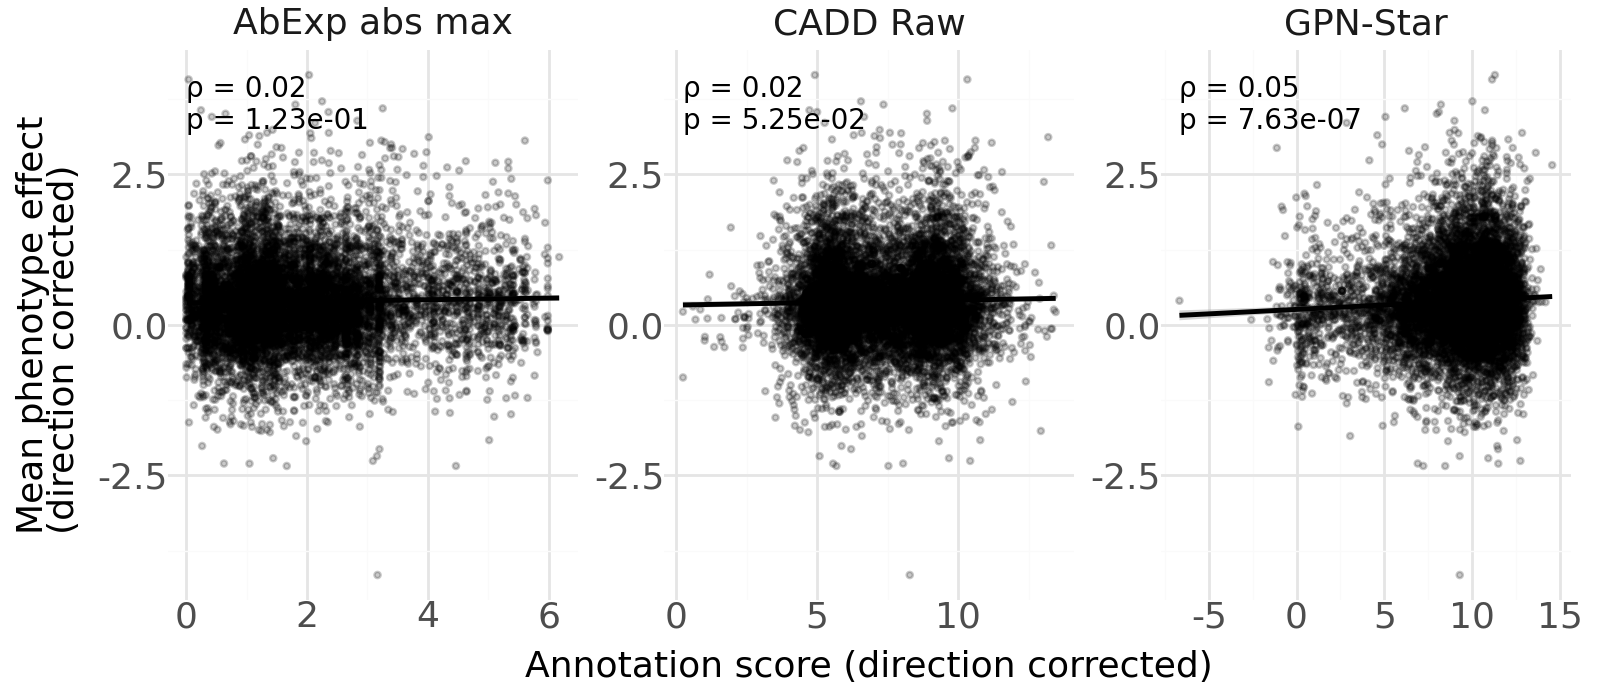

In [19]:
from scipy.stats import spearmanr


# 1. PREPARE DATA
# plot_data = avg_plof_plot
plot_data = avg_plof_plot.filter(
    pl.col('plof_type') == 'loftee_hc'
)

# 2. DEFINE CUSTOM FUNCTION
def get_spearman_stats(df):
    res = spearmanr(df['annotation_score_dircorr'], df['mean_pheno'])
    
    # Use Python's f-string here (it supports .2e, .2f, etc.)
    txt = f"ρ = {res.statistic:.2f}\np = {res.pvalue:.2e}"
    
    return pl.DataFrame({
        "label": df['label'][0],
        "label_text": [txt],  # <--- Return the pre-formatted string
        "x_pos": [df['annotation_score_dircorr'].min()],
        "y_pos": [df['mean_pheno'].max()]
    })

# 3. APPLY TO GROUPS
cor_df = (
    plot_data
    .group_by("label", maintain_order=True)
    .map_groups(get_spearman_stats)
)

# 4. PLOT
(
    ggplot(plot_data, aes(x='annotation_score_dircorr', y='mean_pheno'))
    # + geom_bin_2d(bins=50, aes(fill='..count..'))
    + geom_point(color='black', alpha=0.21, size=0.75)
    + geom_smooth(method='lm', se=True)
    + labs(
        x='Annotation score (direction corrected)',
        y='Mean phenotype effect\n(direction corrected)'
    )
    # Add the text with the p-value
    + geom_text(
        data=cor_df,
        mapping=aes(x='x_pos', y='y_pos', label='label_text'),
        ha='left',
        va='top',
        size=10,
        inherit_aes=False
    )
    + facet_wrap('~label', scales='free', ncol=3)
    # + facet_grid('label_plof~label', scales='free')
    + theme_minimal()
    + theme(
        figure_size=(8, 3.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)